In [8]:
!pip -q install diffusers transformers accelerate safetensors lpips torchmetrics torch-fidelity

In [9]:
import os
import json
import time
import math
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, utils

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from diffusers import AutoencoderKL, DDPMScheduler
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio
import lpips

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Device: cuda


In [11]:
# Update these paths for your Kaggle setup if needed
DATA_ROOT = Path("/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba")
WORK_DIR = Path("/kaggle/working/studentA_celeba_inpainting")
META_DIR = WORK_DIR / "metadata"
RESULT_DIR = WORK_DIR / "results"
GRID_DIR = WORK_DIR / "samples" / "grids"
INDIV_DIR = WORK_DIR / "samples" / "individual"
CKPT_DIR = WORK_DIR / "checkpoints"
ZIP_DIR = WORK_DIR / "zip_outputs"

for p in [WORK_DIR, META_DIR, RESULT_DIR, GRID_DIR, INDIV_DIR, CKPT_DIR, ZIP_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORK_DIR)

Working directory: /kaggle/working/studentA_celeba_inpainting


In [12]:
CFG = {
    "image_size": 256,   # reduced from 512 for faster StudentA_01 run
    "batch_size": 2,     # keep same for now
    "num_workers": 2,
    "epochs": 10,
    "lr": 1e-4,
    "weight_decay": 1e-2,
    "num_train_timesteps": 1000,
    "num_sample_steps": 50,
    "save_every": 1,
    "subset": {
        "train_size": 3000,   # for record only
        "val_size": 500,      # for record only
        "test_size": 500,     # for record only
        "seed": 42,
        "manifest_name": "celeba_fixed_subset_manifest.json"
    },
    "student": {
        "base_ch": 64,
        "time_dim": 256,
        "weight_mask": 4.0
    },
    "eval": {
        "n_test_samples_for_inference": 32,
        "save_grid_count": 8,
        "save_individual_count": 24,
        "n_eval_metrics": 100
    },
    "masking": {
        "rect_prob": 0.30,
        "brush_prob": 0.30,
        "center_prob": 0.15,
        "blob_prob": 0.25,

        "min_holes": 1,
        "max_holes": 4,
        "min_size": 40,
        "max_size": 180,

        "brush_width_min": 12,
        "brush_width_max": 40,
        "brush_strokes_min": 1,
        "brush_strokes_max": 4,
        "points_per_stroke_min": 4,
        "points_per_stroke_max": 8,

        "blob_count_min": 2,
        "blob_count_max": 6,
        "blob_radius_min": 20,
        "blob_radius_max": 80,

        "mask_area_min_ratio": 0.05,
        "mask_area_max_ratio": 0.45
    }
}

In [13]:
all_image_paths = sorted(DATA_ROOT.glob("*.jpg"))
print("Total images found:", len(all_image_paths))
print("Example:", all_image_paths[0] if len(all_image_paths) > 0 else "None")

Total images found: 202599
Example: /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba/000001.jpg


In [15]:
# Cell 7: Load fixed subset directly from existing CSV

subset_csv_path = Path("/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_subset_filenames.csv")

df_subset = pd.read_csv(subset_csv_path)

print("CSV columns:", df_subset.columns.tolist())
print(df_subset["split"].value_counts())

# change 'filename' to 'image_id' if needed
name_col = "filename" if "filename" in df_subset.columns else "image_id"

train_files = df_subset[df_subset["split"] == "train"][name_col].tolist()
val_files   = df_subset[df_subset["split"] == "val"][name_col].tolist()
test_files  = df_subset[df_subset["split"] == "test"][name_col].tolist()

# --------  ADD THIS PART (IMPORTANT) --------
# Reduce dataset size for StudentA_01 fast run

train_files = train_files[:3000]
val_files   = val_files[:500]
test_files  = test_files[:500]

print("\nAfter reduction:")
print("Train:", len(train_files))
print("Val  :", len(val_files))
print("Test :", len(test_files))
# ---------------------------------------------

manifest = {
    "source_csv": str(subset_csv_path),
    "train_size": len(train_files),
    "val_size": len(val_files),
    "test_size": len(test_files),
    "train_files": train_files,
    "val_files": val_files,
    "test_files": test_files
}

manifest_path = META_DIR / "celeba_fixed_subset_manifest_from_csv.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("\nLoaded fixed subset from CSV.")
print("Manifest saved at:", manifest_path)

CSV columns: ['split', 'filename']
split
train    10000
val       1000
test      1000
Name: count, dtype: int64

After reduction:
Train: 3000
Val  : 500
Test : 500

Loaded fixed subset from CSV.
Manifest saved at: /kaggle/working/studentA_celeba_inpainting/metadata/celeba_fixed_subset_manifest_from_csv.json


In [16]:
# Cell 8: Save a local copy of the loaded subset CSV

local_subset_csv_path = META_DIR / "celeba_fixed_subset_filenames.csv"
df_subset.to_csv(local_subset_csv_path, index=False)

print("Saved local copy of subset CSV:", local_subset_csv_path)
df_subset.head()

Saved local copy of subset CSV: /kaggle/working/studentA_celeba_inpainting/metadata/celeba_fixed_subset_filenames.csv


,split,filename
0,train,020294.jpg
1,train,179427.jpg
2,train,023999.jpg
3,train,138391.jpg
4,train,104869.jpg


In [17]:
# Cell 9: Zip metadata

DO_ZIP_METADATA = True
meta_zip_path = ZIP_DIR / "celeba_fixed_subset_metadata.zip"

if DO_ZIP_METADATA:
    with zipfile.ZipFile(meta_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        if manifest_path.exists():
            zf.write(manifest_path, arcname=manifest_path.name)
        if local_subset_csv_path.exists():
            zf.write(local_subset_csv_path, arcname=local_subset_csv_path.name)
    print("Saved metadata zip:", meta_zip_path)
else:
    print("Skipping metadata zip.")

Saved metadata zip: /kaggle/working/studentA_celeba_inpainting/zip_outputs/celeba_fixed_subset_metadata.zip


In [18]:
class FixedSubsetImageDataset(Dataset):
    def __init__(self, data_root, filenames, image_size=512):
        self.data_root = Path(data_root)
        self.filenames = filenames
        self.resize = transforms.Resize((image_size, image_size))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        path = self.data_root / fname
        img = Image.open(path).convert("RGB")
        img = self.resize(img)
        return {
            "filename": fname,
            "image_pil": img
        }

train_ds = FixedSubsetImageDataset(DATA_ROOT, manifest["train_files"], image_size=CFG["image_size"])
val_ds   = FixedSubsetImageDataset(DATA_ROOT, manifest["val_files"], image_size=CFG["image_size"])
test_ds  = FixedSubsetImageDataset(DATA_ROOT, manifest["test_files"], image_size=CFG["image_size"])

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))

Train: 3000
Val  : 500
Test : 500


Cell 11 — Hybrid mask: rectangle

In [19]:
def make_rectangle_mask_pil(size, cfg):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    n_holes = random.randint(cfg["min_holes"], cfg["max_holes"])
    for _ in range(n_holes):
        hole_w = random.randint(cfg["min_size"], min(cfg["max_size"], w // 2))
        hole_h = random.randint(cfg["min_size"], min(cfg["max_size"], h // 2))
        x1 = random.randint(0, w - hole_w)
        y1 = random.randint(0, h - hole_h)
        x2 = x1 + hole_w
        y2 = y1 + hole_h
        draw.rectangle([x1, y1, x2, y2], fill=255)

    return mask

Cell 12 — Hybrid mask: center

In [20]:
def make_center_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    box_w = int(w * 0.4)
    box_h = int(h * 0.4)
    x1 = (w - box_w) // 2
    y1 = (h - box_h) // 2
    x2 = x1 + box_w
    y2 = y1 + box_h

    draw.rectangle([x1, y1, x2, y2], fill=255)
    return mask

In [21]:
def make_brush_mask_pil(size, cfg):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    n_strokes = random.randint(cfg["brush_strokes_min"], cfg["brush_strokes_max"])
    for _ in range(n_strokes):
        n_points = random.randint(cfg["points_per_stroke_min"], cfg["points_per_stroke_max"])
        points = []
        for _ in range(n_points):
            x = random.randint(0, w - 1)
            y = random.randint(0, h - 1)
            points.append((x, y))

        width = random.randint(cfg["brush_width_min"], cfg["brush_width_max"])
        draw.line(points, fill=255, width=width)

        for px, py in points:
            r = width // 2
            draw.ellipse((px-r, py-r, px+r, py+r), fill=255)

    return mask

In [22]:
def make_blob_mask_pil(size, cfg):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    n_blobs = random.randint(cfg["blob_count_min"], cfg["blob_count_max"])

    for _ in range(n_blobs):
        cx = random.randint(0, w - 1)
        cy = random.randint(0, h - 1)
        rx = random.randint(cfg["blob_radius_min"], cfg["blob_radius_max"])
        ry = random.randint(cfg["blob_radius_min"], cfg["blob_radius_max"])

        x1 = max(0, cx - rx)
        y1 = max(0, cy - ry)
        x2 = min(w - 1, cx + rx)
        y2 = min(h - 1, cy + ry)

        draw.ellipse([x1, y1, x2, y2], fill=255)

    mask = mask.filter(ImageFilter.GaussianBlur(radius=6))
    mask_np = np.array(mask)
    mask_np = (mask_np > 80).astype(np.uint8) * 255
    return Image.fromarray(mask_np, mode="L")

In [23]:
def mask_area_ratio(mask_pil):
    mask_np = np.array(mask_pil)
    return float((mask_np > 127).mean())

def sample_hybrid_mask_pil(size, cfg, max_tries=20):
    probs = [
        ("rect", cfg["rect_prob"]),
        ("brush", cfg["brush_prob"]),
        ("center", cfg["center_prob"]),
        ("blob", cfg["blob_prob"])
    ]

    labels = [x[0] for x in probs]
    weights = [x[1] for x in probs]

    for _ in range(max_tries):
        mask_type = random.choices(labels, weights=weights, k=1)[0]

        if mask_type == "rect":
            mask = make_rectangle_mask_pil(size, cfg)
        elif mask_type == "brush":
            mask = make_brush_mask_pil(size, cfg)
        elif mask_type == "center":
            mask = make_center_mask_pil(size)
        else:
            mask = make_blob_mask_pil(size, cfg)

        area = mask_area_ratio(mask)
        if cfg["mask_area_min_ratio"] <= area <= cfg["mask_area_max_ratio"]:
            return mask, mask_type, area

    mask = make_center_mask_pil(size)
    return mask, "center_fallback", mask_area_ratio(mask)

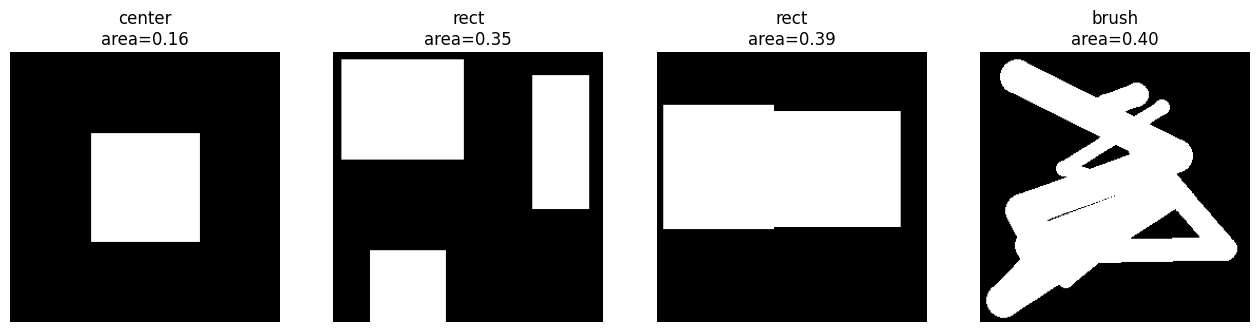

In [24]:
sample_img = test_ds[0]["image_pil"]

plt.figure(figsize=(16, 4))
for i in range(4):
    m, mtype, area = sample_hybrid_mask_pil(sample_img.size, CFG["masking"])
    plt.subplot(1, 4, i+1)
    plt.imshow(m, cmap="gray")
    plt.axis("off")
    plt.title(f"{mtype}\narea={area:.2f}")
plt.show()

In [25]:
to_tensor_01 = transforms.ToTensor()

def pil_to_tensor_01(pil_img):
    return to_tensor_01(pil_img)

def tensor_01_to_pil(t):
    t = t.detach().cpu().clamp(0, 1)
    return transforms.ToPILImage()(t)

def pil_to_tensor_neg1_1(pil_img):
    t = pil_to_tensor_01(pil_img)
    return t * 2.0 - 1.0

def tensor_neg1_1_to_01(t):
    return ((t.clamp(-1, 1) + 1.0) / 2.0)

def apply_mask_to_image(image_pil, mask_pil):
    image_np = np.array(image_pil).copy()
    mask_np = np.array(mask_pil)
    masked_np = image_np.copy()
    masked_np[mask_np > 127] = 0
    return Image.fromarray(masked_np)

In [26]:
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
for p in vae.parameters():
    p.requires_grad = False

scheduler = DDPMScheduler(num_train_timesteps=CFG["num_train_timesteps"])
print("Loaded VAE and scheduler.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loaded VAE and scheduler.


In [27]:
def timestep_embedding(timesteps, dim, max_period=10000):
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32, device=timesteps.device) / half
    )
    args = timesteps.float()[:, None] * freqs[None]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
    return emb

class TimeMLP(nn.Module):
    def __init__(self, time_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(time_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim)
        )

    def forward(self, t):
        return self.net(t)

In [28]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, groups=8):
        super().__init__()
        self.in_ch = in_ch
        self.out_ch = out_ch

        self.norm1 = nn.GroupNorm(groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

class SelfAttention2d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        x_norm = self.norm(x)

        q = self.q(x_norm).reshape(b, c, h*w).permute(0, 2, 1)
        k = self.k(x_norm).reshape(b, c, h*w)
        v = self.v(x_norm).reshape(b, c, h*w).permute(0, 2, 1)

        attn = torch.softmax((q @ k) / (c ** 0.5), dim=-1)
        out = attn @ v
        out = out.permute(0, 2, 1).reshape(b, c, h, w)
        return x + self.proj(out)

In [29]:
class StudentAInpaintUNet(nn.Module):
    def __init__(self, in_ch=9, out_ch=4, base_ch=64, time_dim=256):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = TimeMLP(time_dim)

        self.conv_in = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        self.down1 = ResBlock(base_ch, base_ch, time_dim)
        self.ds1 = Downsample(base_ch)

        self.down2 = ResBlock(base_ch, base_ch * 2, time_dim)
        self.ds2 = Downsample(base_ch * 2)

        self.mid1 = ResBlock(base_ch * 2, base_ch * 4, time_dim)
        self.attn = SelfAttention2d(base_ch * 4)
        self.mid2 = ResBlock(base_ch * 4, base_ch * 4, time_dim)

        self.us2 = Upsample(base_ch * 4)
        self.up2 = ResBlock(base_ch * 4 + base_ch * 2, base_ch * 2, time_dim)

        self.us1 = Upsample(base_ch * 2)
        self.up1 = ResBlock(base_ch * 2 + base_ch, base_ch, time_dim)

        self.norm_out = nn.GroupNorm(8, base_ch)
        self.conv_out = nn.Conv2d(base_ch, out_ch, 3, padding=1)

    def forward(self, x, timesteps):
        t_emb = timestep_embedding(timesteps, self.time_dim)
        t_emb = self.time_mlp(t_emb)

        x0 = self.conv_in(x)

        x1 = self.down1(x0, t_emb)
        x = self.ds1(x1)

        x2 = self.down2(x, t_emb)
        x = self.ds2(x2)

        x = self.mid1(x, t_emb)
        x = self.attn(x)
        x = self.mid2(x, t_emb)

        x = self.us2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, t_emb)

        x = self.us1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x, t_emb)

        x = self.conv_out(F.silu(self.norm_out(x)))
        return x

model = StudentAInpaintUNet(
    in_ch=9,
    out_ch=4,
    base_ch=CFG["student"]["base_ch"],
    time_dim=CFG["student"]["time_dim"]
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print("Student A params:", total_params)

Student A params: 5871492


In [30]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)
print("Optimizer ready.")

Optimizer ready.


In [31]:
def encode_to_latent_from_pil_list(pil_list):
    imgs = torch.stack([pil_to_tensor_neg1_1(im) for im in pil_list]).to(device)
    with torch.no_grad():
        latents = vae.encode(imgs).latent_dist.sample() * 0.18215
    return imgs, latents

def prepare_train_batch(samples):
    orig_pils = [s["image_pil"] for s in samples]
    filenames = [s["filename"] for s in samples]

    masks_pil = []
    mask_types = []
    mask_areas = []
    masked_pils = []

    for img in orig_pils:
        mask, mtype, area = sample_hybrid_mask_pil(img.size, CFG["masking"])
        masked = apply_mask_to_image(img, mask)

        masks_pil.append(mask)
        mask_types.append(mtype)
        mask_areas.append(area)
        masked_pils.append(masked)

    orig_t, latents = encode_to_latent_from_pil_list(orig_pils)
    _, masked_latents = encode_to_latent_from_pil_list(masked_pils)

    mask_t = torch.stack([
        pil_to_tensor_01(m).float() for m in masks_pil
    ]).to(device)

    return {
        "filenames": filenames,
        "orig_pils": orig_pils,
        "masked_pils": masked_pils,
        "masks_pil": masks_pil,
        "mask_types": mask_types,
        "mask_areas": mask_areas,
        "orig_t": orig_t,
        "latents": latents,
        "masked_latents": masked_latents,
        "mask_t": mask_t
    }

In [32]:
def collate_identity(batch):
    return batch

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    collate_fn=collate_identity
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    collate_fn=collate_identity
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 1500
Val batches: 250


In [33]:
def masked_weighted_noise_loss(pred_noise, true_noise, mask_t, weight_mask=4.0):
    mask_lat = F.interpolate(mask_t, size=pred_noise.shape[-2:], mode="nearest")
    weight = 1.0 + (weight_mask - 1.0) * mask_lat
    return (weight * (pred_noise - true_noise) ** 2).mean()

In [34]:
def run_one_step(sample_batch, train_mode=True):
    batch = prepare_train_batch(sample_batch)

    latents = batch["latents"]
    masked_latents = batch["masked_latents"]
    mask_t = batch["mask_t"]

    noise = torch.randn_like(latents)
    timesteps = torch.randint(
        0, CFG["num_train_timesteps"], (latents.size(0),), device=device
    ).long()

    noisy_latents = scheduler.add_noise(latents, noise, timesteps)
    mask_lat = F.interpolate(mask_t, size=noisy_latents.shape[-2:], mode="nearest")
    model_input = torch.cat([noisy_latents, mask_lat, masked_latents], dim=1)

    if train_mode:
        model.train()
        optimizer.zero_grad()
        pred_noise = model(model_input, timesteps)
        loss = masked_weighted_noise_loss(
            pred_noise, noise, mask_t, CFG["student"]["weight_mask"]
        )
        loss.backward()
        optimizer.step()
    else:
        model.eval()
        with torch.no_grad():
            pred_noise = model(model_input, timesteps)
            loss = masked_weighted_noise_loss(
                pred_noise, noise, mask_t, CFG["student"]["weight_mask"]
            )

    return float(loss.item())

In [35]:
history = []
best_ckpt_path = CKPT_DIR / "studentA_best.pt"
latest_ckpt_path = CKPT_DIR / "studentA_latest.pt"
best_val = float("inf")

for epoch in range(1, CFG["epochs"] + 1):
    train_losses = []
    val_losses = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch} Train"):
        loss = run_one_step(batch, train_mode=True)
        train_losses.append(loss)

    for batch in tqdm(val_loader, desc=f"Epoch {epoch} Val"):
        loss = run_one_step(batch, train_mode=False)
        val_losses.append(loss)

    train_total = float(np.mean(train_losses))
    val_total = float(np.mean(val_losses))

    history.append({
        "epoch": epoch,
        "train_total": train_total,
        "val_total": val_total
    })

    print(f"Epoch {epoch}: train={train_total:.4f}, val={val_total:.4f}")

    # save latest every epoch
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val": best_val,
        "history": history,
        "cfg": CFG
    }, latest_ckpt_path)

    if val_total < best_val:
        best_val = val_total
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val": best_val,
            "history": history,
            "cfg": CFG
        }, best_ckpt_path)
        print("Saved best checkpoint:", best_ckpt_path)

history_path = RESULT_DIR / "studentA_train_history.csv"
pd.DataFrame(history).to_csv(history_path, index=False)
print("Saved training history:", history_path)
print("Saved latest checkpoint:", latest_ckpt_path)

Epoch 1 Train:   0%|          | 0/1500 [00:00<?, ?it/s]

/tmp/ipykernel_55/2716138634.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(mask_np, mode="L")


Epoch 1 Val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1: train=0.3961, val=0.2656
Saved best checkpoint: /kaggle/working/studentA_celeba_inpainting/checkpoints/studentA_best.pt


Epoch 2 Train:   0%|          | 0/1500 [00:00<?, ?it/s]

...

Epoch 9 Val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 9: train=0.2127, val=0.1868
Saved best checkpoint: /kaggle/working/studentA_celeba_inpainting/checkpoints/studentA_best.pt


Epoch 10 Train:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 10 Val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 10: train=0.2172, val=0.2145
Saved training history: /kaggle/working/studentA_celeba_inpainting/results/studentA_train_history.csv
Saved latest checkpoint: /kaggle/working/studentA_celeba_inpainting/checkpoints/studentA_latest.pt


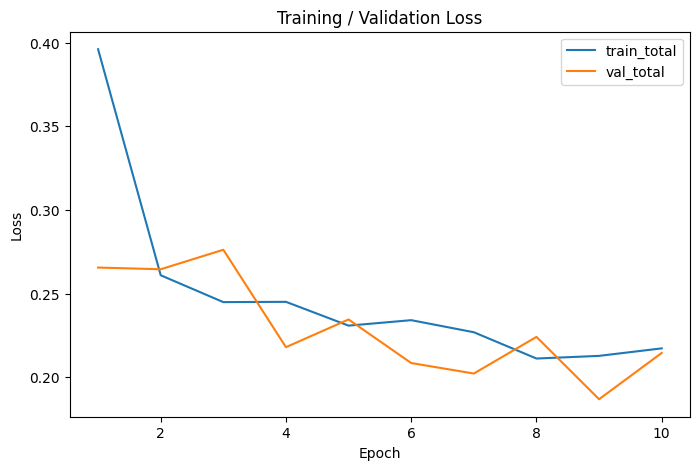

In [36]:
hist_df = pd.DataFrame(history)

plt.figure(figsize=(8, 5))
plt.plot(hist_df["epoch"], hist_df["train_total"], label="train_total")
plt.plot(hist_df["epoch"], hist_df["val_total"], label="val_total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training / Validation Loss")
plt.show()

In [37]:
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("Loaded best checkpoint from epoch:", ckpt["epoch"])

Loaded best checkpoint from epoch: 9


In [38]:
@torch.no_grad()
def run_student_inpaint(model, image_pil, mask_pil, num_sample_steps=50):
    model.eval()

    orig_t = pil_to_tensor_neg1_1(image_pil).unsqueeze(0).to(device)
    masked_pil = apply_mask_to_image(image_pil, mask_pil)
    masked_t = pil_to_tensor_neg1_1(masked_pil).unsqueeze(0).to(device)

    masked_latents = vae.encode(masked_t).latent_dist.sample() * 0.18215
    latents = torch.randn_like(masked_latents)

    mask_t = pil_to_tensor_01(mask_pil).unsqueeze(0).to(device)
    scheduler.set_timesteps(num_sample_steps)

    for t in scheduler.timesteps:
        mask_lat = F.interpolate(mask_t, size=latents.shape[-2:], mode="nearest")
        model_input = torch.cat([latents, mask_lat, masked_latents], dim=1)

        t_batch = torch.full((1,), int(t), device=device, dtype=torch.long)
        noise_pred = model(model_input, t_batch)

        latents = scheduler.step(noise_pred, t, latents).prev_sample

    decoded = vae.decode(latents / 0.18215).sample
    pred_01 = tensor_neg1_1_to_01(decoded[0])
    pred_pil = tensor_01_to_pil(pred_01)

    return pred_pil

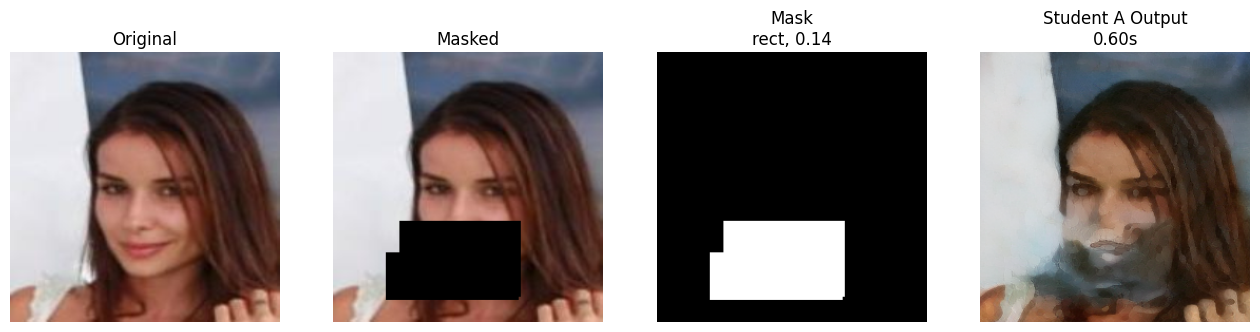

In [39]:
sample = test_ds[0]
orig = sample["image_pil"]
mask, mask_type, area = sample_hybrid_mask_pil(orig.size, CFG["masking"])
masked = apply_mask_to_image(orig, mask)

start = time.time()
pred = run_student_inpaint(model, orig, mask, CFG["num_sample_steps"])
elapsed = time.time() - start

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(masked)
plt.title("Masked")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(mask, cmap="gray")
plt.title(f"Mask\n{mask_type}, {area:.2f}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred)
plt.title(f"Student A Output\n{elapsed:.2f}s")
plt.axis("off")

plt.show()

In [40]:
n_eval = min(CFG["eval"]["n_test_samples_for_inference"], len(test_ds))
save_grid_count = min(CFG["eval"]["save_grid_count"], n_eval)
save_individual_count = min(CFG["eval"]["save_individual_count"], n_eval)

records = []
grid_items = []

for i in tqdm(range(n_eval), desc="Student A baseline inference"):
    sample = test_ds[i]
    fname = sample["filename"]
    orig = sample["image_pil"]

    mask, mask_type, area = sample_hybrid_mask_pil(orig.size, CFG["masking"])
    masked = apply_mask_to_image(orig, mask)

    start = time.time()
    pred = run_student_inpaint(model, orig, mask, CFG["num_sample_steps"])
    elapsed = time.time() - start

    if i < save_individual_count:
        orig_path   = INDIV_DIR / f"{i:04d}_{Path(fname).stem}_orig.png"
        masked_path = INDIV_DIR / f"{i:04d}_{Path(fname).stem}_masked.png"
        mask_path   = INDIV_DIR / f"{i:04d}_{Path(fname).stem}_mask.png"
        pred_path   = INDIV_DIR / f"{i:04d}_{Path(fname).stem}_pred.png"

        orig.save(orig_path)
        masked.save(masked_path)
        mask.save(mask_path)
        pred.save(pred_path)
    else:
        orig_path = ""
        masked_path = ""
        mask_path = ""
        pred_path = ""

    records.append({
        "index": i,
        "filename": fname,
        "mask_type": mask_type,
        "mask_area_ratio": round(area, 4),
        "inference_time_sec": round(elapsed, 4),
        "orig_path": str(orig_path),
        "masked_path": str(masked_path),
        "mask_path": str(mask_path),
        "pred_path": str(pred_path)
    })

    if i < save_grid_count:
        mask_rgb = Image.merge("RGB", (mask, mask, mask))
        grid_items.append((orig, masked, mask_rgb, pred, mask_type, fname))

df_records = pd.DataFrame(records)
result_csv = RESULT_DIR / "studentA_baseline_inference_log.csv"
df_records.to_csv(result_csv, index=False)

print("Saved inference log:", result_csv)
df_records.head()

Student A baseline inference:   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_55/2716138634.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(mask_np, mode="L")


Saved inference log: /kaggle/working/studentA_celeba_inpainting/results/studentA_baseline_inference_log.csv


,index,filename,mask_type,mask_area_ratio,inference_time_sec,orig_path,masked_path,mask_path,pred_path
0,0,185385.jpg,brush,0.4296,0.4202,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...
1,1,126390.jpg,rect,0.2146,0.4193,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...
2,2,093644.jpg,rect,0.0821,0.4193,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...
3,3,112214.jpg,brush,0.1486,0.4258,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...
4,4,088630.jpg,center,0.1619,0.4193,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...,/kaggle/working/studentA_celeba_inpainting/sam...


In [41]:
grid_tensors = []
for orig, masked, mask_rgb, pred, _, _ in grid_items:
    grid_tensors.extend([
        pil_to_tensor_01(orig),
        pil_to_tensor_01(masked),
        pil_to_tensor_01(mask_rgb),
        pil_to_tensor_01(pred)
    ])

grid = utils.make_grid(torch.stack(grid_tensors), nrow=4)
grid_path = GRID_DIR / "studentA_baseline_grid_main.png"
utils.save_image(grid, grid_path)

print("Saved main grid:", grid_path)

Saved main grid: /kaggle/working/studentA_celeba_inpainting/samples/grids/studentA_baseline_grid_main.png


In [42]:
masktype_to_items = {}

for item in grid_items:
    _, _, _, _, mtype, _ = item
    masktype_to_items.setdefault(mtype, []).append(item)

for mtype, items in masktype_to_items.items():
    small_tensors = []
    for orig, masked, mask_rgb, pred, _, _ in items[:4]:
        small_tensors.extend([
            pil_to_tensor_01(orig),
            pil_to_tensor_01(masked),
            pil_to_tensor_01(mask_rgb),
            pil_to_tensor_01(pred)
        ])

    if len(small_tensors) > 0:
        small_grid = utils.make_grid(torch.stack(small_tensors), nrow=4)
        small_grid_path = GRID_DIR / f"studentA_grid_{mtype}.png"
        utils.save_image(small_grid, small_grid_path)
        print("Saved:", small_grid_path)

Saved: /kaggle/working/studentA_celeba_inpainting/samples/grids/studentA_grid_brush.png
Saved: /kaggle/working/studentA_celeba_inpainting/samples/grids/studentA_grid_rect.png
Saved: /kaggle/working/studentA_celeba_inpainting/samples/grids/studentA_grid_center.png


In [43]:
avg_time = df_records["inference_time_sec"].mean()
std_time = df_records["inference_time_sec"].std()

mask_stats = (
    df_records.groupby("mask_type")["mask_area_ratio"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

mask_stats_csv = RESULT_DIR / "studentA_mask_stats.csv"
mask_stats.to_csv(mask_stats_csv, index=False)

summary = {
    "model_name": "StudentA_Latent_Inpainting_Baseline",
    "image_size": CFG["image_size"],
    "n_eval_samples": int(n_eval),
    "avg_inference_time_sec": round(float(avg_time), 4),
    "std_inference_time_sec": round(float(std_time), 4),
    "subset_manifest": str(manifest_path),
    "subset_csv": str(local_subset_csv_path),
    "main_grid_path": str(grid_path),
    "mask_stats_csv": str(mask_stats_csv),
    "individual_outputs_saved": int(save_individual_count),
    "params": int(total_params),
    "sampling_steps": int(CFG["num_sample_steps"])
}

summary_path = RESULT_DIR / "studentA_baseline_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("Saved summary:", summary_path)
print(mask_stats)

{
  "model_name": "StudentA_Latent_Inpainting_Baseline",
  "image_size": 256,
  "n_eval_samples": 32,
  "avg_inference_time_sec": 0.427,
  "std_inference_time_sec": 0.0119,
  "subset_manifest": "/kaggle/working/studentA_celeba_inpainting/metadata/celeba_fixed_subset_manifest_from_csv.json",
  "subset_csv": "/kaggle/working/studentA_celeba_inpainting/metadata/celeba_fixed_subset_filenames.csv",
  "main_grid_path": "/kaggle/working/studentA_celeba_inpainting/samples/grids/studentA_baseline_grid_main.png",
  "mask_stats_csv": "/kaggle/working/studentA_celeba_inpainting/results/studentA_mask_stats.csv",
  "individual_outputs_saved": 24,
  "params": 5871492,
  "sampling_steps": 50
}
Saved summary: /kaggle/working/studentA_celeba_inpainting/results/studentA_baseline_summary.json
  mask_type  count      mean       std     min     max
0      blob      5  0.267440  0.118135  0.1523  0.4129
1     brush      8  0.299575  0.119666  0.1460  0.4296
2    center      7  0.161900  0.000000  0.1619  0.1

In [44]:
fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()
print("Metric models ready.")

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 228MB/s]


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 193MB/s]  


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Metric models ready.


In [45]:
N_EVAL_METRICS = min(CFG["eval"]["n_eval_metrics"], len(test_ds))

psnr_vals = []
ssim_vals = []
lpips_vals = []

fid_metric.reset()

for i in tqdm(range(N_EVAL_METRICS), desc="Student A metric evaluation"):
    sample = test_ds[i]
    orig = sample["image_pil"]

    mask, _, _ = sample_hybrid_mask_pil(orig.size, CFG["masking"])
    pred = run_student_inpaint(model, orig, mask, CFG["num_sample_steps"])

    orig_t = pil_to_tensor_01(orig).unsqueeze(0).to(device)
    pred_t = pil_to_tensor_01(pred).unsqueeze(0).to(device)

    mask_np = (np.array(mask) > 127).astype(np.float32)
    mask_t = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).to(device)
    mask_t = mask_t.repeat(1, 3, 1, 1)

    orig_region = orig_t * mask_t
    pred_region = pred_t * mask_t

    psnr_vals.append(psnr_metric(pred_region, orig_region).item())
    ssim_vals.append(ssim_metric(pred_region, orig_region).item())
    lpips_vals.append(
        lpips_model(pred_region * 2 - 1, orig_region * 2 - 1).item()
    )

    fid_metric.update(orig_t, real=True)
    fid_metric.update(pred_t, real=False)

Student A metric evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_55/2716138634.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(mask_np, mode="L")


In [46]:
results = {
    "FID": round(float(fid_metric.compute().item()), 3),
    "PSNR_masked": round(float(np.mean(psnr_vals)), 3),
    "SSIM_masked": round(float(np.mean(ssim_vals)), 3),
    "LPIPS_masked": round(float(np.mean(lpips_vals)), 3),
    "avg_inference_time_sec": round(float(avg_time), 4),
    "std_inference_time_sec": round(float(std_time), 4),
    "n_eval_metrics": int(N_EVAL_METRICS),
    "params": int(total_params),
    "sampling_steps": int(CFG["num_sample_steps"])
}

print("Student A Evaluation Results:")
for k, v in results.items():
    print(f"{k}: {v}")

Student A Evaluation Results:
FID: 260.215
PSNR_masked: 18.287
SSIM_masked: 0.844
LPIPS_masked: 0.156
avg_inference_time_sec: 0.427
std_inference_time_sec: 0.0119
n_eval_metrics: 100
params: 5871492
sampling_steps: 50


In [47]:
metrics_json_path = RESULT_DIR / "studentA_metrics.json"
with open(metrics_json_path, "w") as f:
    json.dump(results, f, indent=2)

print("Saved metrics:", metrics_json_path)

Saved metrics: /kaggle/working/studentA_celeba_inpainting/results/studentA_metrics.json


In [49]:
report_text = f"""
Student A Lightweight Inpainting Report
======================================

1. Experiment Overview
----------------------
Experiment type: Lightweight latent diffusion student baseline
Model name: StudentA_Latent_Inpainting_Baseline
Image size: {CFG["image_size"]}
Sampling steps: {CFG["num_sample_steps"]}

2. Fixed Dataset Subset
-----------------------
# Train size: {CFG["subset"]["train_size"]}
# Validation size: {CFG["subset"]["val_size"]}
# Test size: {CFG["subset"]["test_size"]}

Train size: {len(train_files)}
Validation size: {len(val_files)}
Test size: {len(test_files)}
Subset seed: {CFG["subset"]["seed"]}

Fixed subset manifest path:
{manifest_path}

Fixed subset CSV path:
{subset_csv_path}

3. Student Model
----------------
Input conditioning:
- noisy latent
- mask
- masked image latent

Parameter count:
{total_params}

4. Hybrid Mask Strategy
-----------------------
The student baseline was trained and evaluated using:
- rectangle masks
- brush / irregular masks
- center masks
- blob / object-like masks

Mask probabilities:
- rectangle: {CFG["masking"]["rect_prob"]}
- brush: {CFG["masking"]["brush_prob"]}
- center: {CFG["masking"]["center_prob"]}
- blob: {CFG["masking"]["blob_prob"]}

Mask area ratio range:
- minimum: {CFG["masking"]["mask_area_min_ratio"]}
- maximum: {CFG["masking"]["mask_area_max_ratio"]}

5. Runtime Statistics
---------------------
Average inference time per image (sec): {avg_time:.4f}
Standard deviation of inference time (sec): {std_time:.4f}

6. Quantitative Results
-----------------------
FID: {results["FID"]}
PSNR_masked: {results["PSNR_masked"]}
SSIM_masked: {results["SSIM_masked"]}
LPIPS_masked: {results["LPIPS_masked"]}
n_eval_metrics: {results["n_eval_metrics"]}

7. Notes
--------
This Student A notebook is the lightweight baseline before adding teacher distillation.
It uses the same fixed subset and same hybrid masking family as the SD2 baseline,
so comparison is fairer than using a different split or different mask pipeline.
"""

report_txt_path = RESULT_DIR / "studentA_baseline_report.txt"
with open(report_txt_path, "w") as f:
    f.write(report_text)

print("Saved report:", report_txt_path)

Saved report: /kaggle/working/studentA_celeba_inpainting/results/studentA_baseline_report.txt


In [50]:
DO_ZIP_RESULTS = True
results_zip_path = ZIP_DIR / "studentA_baseline_outputs.zip"

if DO_ZIP_RESULTS:
    with zipfile.ZipFile(results_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        key_files = [
            manifest_path,
            local_subset_csv_path,
            history_path,
            result_csv,
            summary_path,
            mask_stats_csv,
            metrics_json_path,
            report_txt_path,
            grid_path,
            best_ckpt_path
        ]

        for p in key_files:
            if Path(p).exists():
                zf.write(p, arcname=Path(p).name)

    print("Saved results zip:", results_zip_path)
else:
    print("Skipping result zip.")

Saved results zip: /kaggle/working/studentA_celeba_inpainting/zip_outputs/studentA_baseline_outputs.zip


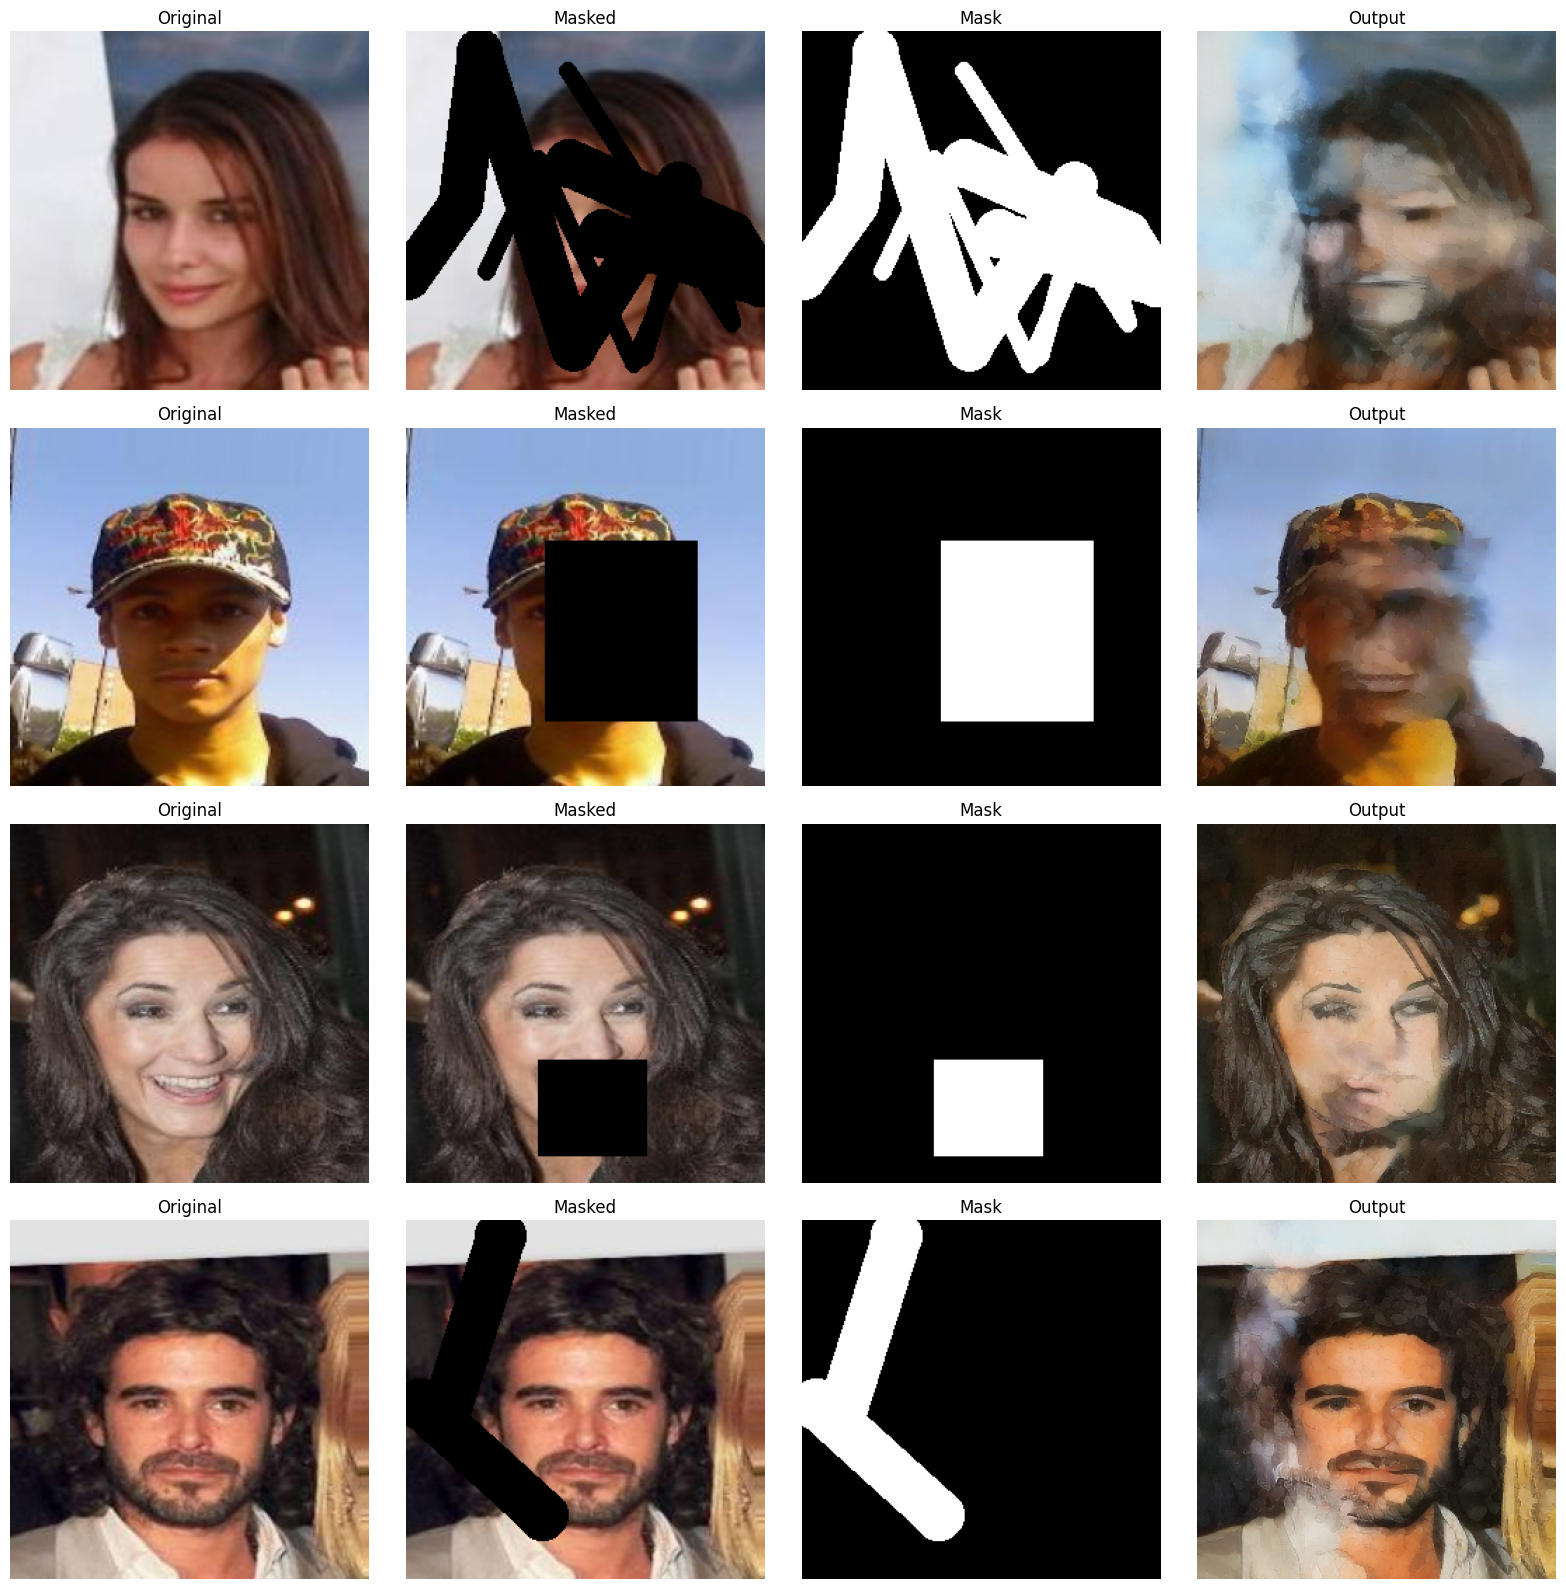

In [51]:
saved_preds = sorted(INDIV_DIR.glob("*_pred.png"))[:4]
saved_masks = sorted(INDIV_DIR.glob("*_mask.png"))[:4]
saved_masked = sorted(INDIV_DIR.glob("*_masked.png"))[:4]
saved_orig = sorted(INDIV_DIR.glob("*_orig.png"))[:4]

plt.figure(figsize=(16, 16))

for i in range(min(4, len(saved_preds))):
    orig = Image.open(saved_orig[i])
    masked = Image.open(saved_masked[i])
    mask = Image.open(saved_masks[i])
    pred = Image.open(saved_preds[i])

    row = i * 4

    plt.subplot(4, 4, row + 1)
    plt.imshow(orig)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(4, 4, row + 2)
    plt.imshow(masked)
    plt.axis("off")
    plt.title("Masked")

    plt.subplot(4, 4, row + 3)
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.title("Mask")

    plt.subplot(4, 4, row + 4)
    plt.imshow(pred)
    plt.axis("off")
    plt.title("Output")

plt.tight_layout()
plt.show()

In [52]:
comparison_df = pd.DataFrame([
    {
        "Model": "SD1.5 Inpainting",
        "Params": None,
        "FID": None,
        "PSNR_masked": None,
        "SSIM_masked": None,
        "LPIPS_masked": None,
        "Avg_Inference_sec": None,
        "Sampling_Steps": None
    },
    {
        "Model": "SD2 Inpainting",
        "Params": None,
        "FID": 22.0,
        "PSNR_masked": 26.85,
        "SSIM_masked": 0.94,
        "LPIPS_masked": 0.04,
        "Avg_Inference_sec": 5.8,
        "Sampling_Steps": 30
    },
    {
        "Model": "Student A",
        "Params": results["params"],
        "FID": results["FID"],
        "PSNR_masked": results["PSNR_masked"],
        "SSIM_masked": results["SSIM_masked"],
        "LPIPS_masked": results["LPIPS_masked"],
        "Avg_Inference_sec": results["avg_inference_time_sec"],
        "Sampling_Steps": results["sampling_steps"]
    }
])

comparison_df

,Model,Params,FID,PSNR_masked,SSIM_masked,LPIPS_masked,Avg_Inference_sec,Sampling_Steps
0,SD1.5 Inpainting,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SD2 Inpainting,NaN,22.000,26.850,0.940,0.040,5.800,30.0
2,Student A,5871492.0,260.215,18.287,0.844,0.156,0.427,50.0


Experiment:
Stable Diffusion 2 baseline rerun under the SAME split and SAME image size protocol as Student A02.

Dataset split:
Train = 3000
Val   = 500
Test  = 500

Image size:
256

Teacher settings:
Model ID        : sd2-community/stable-diffusion-2-inpainting
Inference steps : 100
Guidance scale  : 7.5
Prompt          : a realistic high-quality human face

Metrics:
FID             : 27.071
PSNR_masked     : 24.929
SSIM_masked     : 0.897
LPIPS_masked    : 0.064
Avg inference   : 15.2870 sec/image
Parameter       :50M+

In [53]:
print(f"""
================ EXPERIMENT SUMMARY ================

Experiment Stage:
Lightweight Student A Baseline for Image Inpainting

Project:
CSE499B - Lightweight Diffusion Models for Image Inpainting

---------------------------------------------------
Context:
- SD 1.5 and SD 2 inpainting baselines already evaluated
- SD 2 used as main teacher baseline
- Goal: Build lightweight model with comparable quality-efficiency tradeoff

---------------------------------------------------
Student Model Details:
- Latent-space diffusion inpainting
- Input: noisy latent + mask + masked-image latent
- Lightweight UNet-style denoiser
- Trained on CelebA fixed subset
- Same hybrid masking family as baseline:
  rectangle / brush / center / blob

---------------------------------------------------
Evaluation Metrics (THIS RUN):

FID: {results['FID']:.3f}
PSNR_masked: {results['PSNR_masked']:.3f}
SSIM_masked: {results['SSIM_masked']:.3f}
LPIPS_masked: {results['LPIPS_masked']:.3f}
Avg Inference Time (sec/image): {results['avg_inference_time_sec']:.4f}
Parameter Count: {results['params']}
Sampling Steps: {results['sampling_steps']}

---------------------------------------------------
Teacher Baseline (SD2 Reference img size 512):
Trained on 10000,test 1000 ,val 1000

FID ≈ 22
PSNR_masked ≈ 26.85
SSIM_masked ≈ 0.94
LPIPS ≈ 0.04
Inference ≈ 5.8 sec/image

---------------------------------------------------
Interpretation:
- This notebook establishes the first lightweight student baseline.
- Comparison against SD2 should focus on:
  1. quality gap
  2. structural similarity
  3. perceptual similarity
  4. efficiency gain from lower params / runtime

---------------------------------------------------
Next Steps:
1. Add teacher distillation from SD2
2. Train Student B as stronger compression ablation
3. Re-run same evaluation pipeline for fair comparison

====================================================
""")


================ EXPERIMENT SUMMARY ================

Experiment Stage:
Lightweight Student A Baseline for Image Inpainting

Project:
CSE499B - Lightweight Diffusion Models for Image Inpainting

---------------------------------------------------
Context:
- SD 1.5 and SD 2 inpainting baselines already evaluated
- SD 2 used as main teacher baseline
- Goal: Build lightweight model with comparable quality-efficiency tradeoff

---------------------------------------------------
Student Model Details:
- Latent-space diffusion inpainting
- Input: noisy latent + mask + masked-image latent
- Lightweight UNet-style denoiser
- Trained on CelebA fixed subset
- Same hybrid masking family as baseline:
  rectangle / brush / center / blob

---------------------------------------------------
Evaluation Metrics (THIS RUN):

FID: 260.215
PSNR_masked: 18.287
SSIM_masked: 0.844
LPIPS_masked: 0.156
Avg Inference Time (sec/image): 0.4270
Parameter Count: 5871492
Sampling Steps: 50

------------------------

Experiment:
Stable Diffusion 2 baseline rerun under the SAME split and SAME image size protocol as Student A02.

Dataset split:
Train = 3000
Val   = 500
Test  = 500

Image size:
256

Teacher settings:
Model ID        : sd2-community/stable-diffusion-2-inpainting
Inference steps : 100
Guidance scale  : 7.5
Prompt          : a realistic high-quality human face

Metrics:
FID             : 27.071
PSNR_masked     : 24.929
SSIM_masked     : 0.897
LPIPS_masked    : 0.064
Avg inference   : 15.2870 sec/image